# Chatbot with Profile Schema 

## Review

우리는 장기 기억을 저장하고 검색하는 방법으로 [LangGraph Memory Store](https://reference.langchain.com/python/langgraph/store/?h=basestor#langgraph.store.base.BaseStore)를 도입했습니다.

단기(스레드 내) 및 장기(스레드 간) 메모리를 모두 사용하는 간단한 챗봇을 구축했습니다.

사용자와 대화하는 동안 장기적인 [Semantic Memory](https://docs.langchain.com/oss/python/concepts/memory#semantic-memory) (사용자에 관한 사실들)을 [“핫 패스(hot path)”](https://docs.langchain.com/oss/python/concepts/memory#writing-memories)에 저장했습니다.

## Goals

우리 챗봇은 기억을 문자열로 저장했습니다. 실제로는 기억에 구조를 부여하고 싶은 경우가 많습니다.

예를 들어, 기억은 [단일하고 지속적으로 업데이트되는 스키마](https://docs.langchain.com/oss/python/concepts/memory#profile)일 수 있습니다.

우리의 경우, 이를 단일 사용자 프로필로 만들고자 합니다.
 
우리는 챗봇을 확장하여 의미론적 기억을 단일 [사용자 프로필](https://docs.langchain.com/oss/python/concepts/memory#profile)에 저장하도록 할 것입니다.

또한 새로운 정보로 이 스키마를 업데이트하기 위해 [Trustcall](https://github.com/hinthornw/trustcall) 라이브러리를 도입할 것입니다. 

In [1]:
# %%capture --no-stderr
# %pip install -U langchain_openai langgraph trustcall langchain_core

In [2]:
# import os, getpass

# def _set_env(var: str):
#     # Check if the variable is set in the OS environment
#     env_value = os.environ.get(var)
#     if not env_value:
#         # If not set, prompt the user for input
#         env_value = getpass.getpass(f"{var}: ")
    
#     # Set the environment variable for the current process
#     os.environ[var] = env_value

# _set_env("LANGSMITH_API_KEY")
# os.environ["LANGSMITH_TRACING"] = "true"
# os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

from dotenv import load_dotenv

load_dotenv("../../.env")

True

## Defining a user profile schema

파이썬은 [구조화된 데이터](https://docs.langchain.com/oss/python/langchain/models#structured-outputs)를 위한 다양한 유형을 제공합니다. 예를 들어 TypedDict, Dictionaries, JSON, 그리고 [Pydantic](https://docs.pydantic.dev/latest/) 등이 있습니다.

TypedDict를 사용하여 사용자 프로필 스키마를 정의하는 것부터 시작해 보겠습니다.

In [3]:
from typing import TypedDict, List

class UserProfile(TypedDict):
    """User profile schema with typed fields"""
    user_name: str  # The user's preferred name
    interests: List[str]  # A list of the user's interests

## Saving a schema to the store

[LangGraph Store](https://reference.langchain.com/python/langgraph/store/?h=basestor#langgraph.store.base.BaseStore)는 `value`로 어떤 Python dictionary도 허용합니다. 

In [4]:
# TypedDict instance
user_profile: UserProfile = {
    "user_name": "Lance",
    "interests": ["biking", "technology", "coffee"]
}
user_profile

{'user_name': 'Lance', 'interests': ['biking', 'technology', 'coffee']}

저장소에 TypedDict를 저장하기 위해 [put](https://reference.langchain.com/python/langgraph/store/?h=basestor#langgraph.store.base.BaseStore.put) 메서드를 사용합니다.

In [5]:
import uuid
from langgraph.store.memory import InMemoryStore

# Initialize the in-memory store
in_memory_store = InMemoryStore()

# Namespace for the memory to save
user_id = "1"
namespace_for_memory = (user_id, "memory")

# Save a memory to namespace as key and value
key = "user_profile"
value = user_profile
in_memory_store.put(namespace_for_memory, key, value)

In [6]:
in_memory_store

We use [search](https://reference.langchain.com/python/langgraph/store/?h=basestor#langgraph.store.base.BaseStore.search) to retrieve objects from the store by namespace.

In [7]:
# Search 
for m in in_memory_store.search(namespace_for_memory):
    print(m.dict())

{'namespace': ['1', 'memory'], 'key': 'user_profile', 'value': {'user_name': 'Lance', 'interests': ['biking', 'technology', 'coffee']}, 'created_at': '2026-03-24T00:30:29.272838+00:00', 'updated_at': '2026-03-24T00:30:29.272841+00:00', 'score': None}


In [8]:
in_memory_store.search(namespace_for_memory)

[Item(namespace=['1', 'memory'], key='user_profile', value={'user_name': 'Lance', 'interests': ['biking', 'technology', 'coffee']}, created_at='2026-03-24T00:30:29.272838+00:00', updated_at='2026-03-24T00:30:29.272841+00:00', score=None)]

We can also use [get](https://reference.langchain.com/python/langgraph/store/?h=basestor#langgraph.store.base.BaseStore.get) to retrieve a specific object by namespace and key.

In [9]:
# Get the memory by namespace and key
profile = in_memory_store.get(namespace_for_memory, "user_profile")
profile.value

{'user_name': 'Lance', 'interests': ['biking', 'technology', 'coffee']}

## Chatbot with profile schema

이제 우리는 기억에 대한 스키마를 지정하고 저장소에 저장하는 방법을 알게 되었습니다.

그렇다면 이 특정 스키마로 실제로 기억을 *생성*하는 방법은 무엇일까요?

우리 챗봇에서는 [사용자 대화로부터 기억을 생성하고자 합니다](https://docs.langchain.com/oss/python/concepts/memory#profile). 

이때 [구조화된 출력](https://docs.langchain.com/oss/python/langchain/models#structured-outputs) 개념이 유용합니다. 

LangChain의 [챗 모델](https://docs.langchain.com/oss/python/langchain/models) 인터페이스에는 구조화된 출력을 강제하는 [`with_structured_output`](https://docs.langchain.com/oss/python/langchain/models#structured-outputs) 메서드가 있습니다.

이는 출력이 특정 스키마를 준수하도록 강제하고, 출력을 자동으로 파싱해 주는 데 유용합니다.

In [8]:
# _set_env("OPENAI_API_KEY")

생성한 `UserProfile` 스키마를 `with_structured_output` 메서드에 전달합시다.

그런 다음 [메시지](https://docs.langchain.com/oss/python/langchain/messages) 목록과 함께 채팅 모델을 호출하면 스키마에 부합하는 구조화된 출력을 얻을 수 있습니다.

In [10]:
from pydantic import BaseModel, Field

from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI

# Initialize the model
model = ChatOpenAI(model="gpt-4o", temperature=0)

# Bind schema to model
model_with_structure = model.with_structured_output(UserProfile)

# Invoke the model to produce structured output that matches the schema
structured_output = model_with_structure.invoke([HumanMessage("저는 유광명입니다. 테니스 치는 것을 좋아해요.")])
structured_output

{'user_name': '유광명', 'interests': ['테니스']}

이제 이 기능을 챗봇에 적용해 보겠습니다.

`write_memory` 함수에서 약간의 수정만 하면 됩니다.

위에서 정의한 `model_with_structure`를 사용하여 스키마에 맞는 프로필을 생성합니다. 

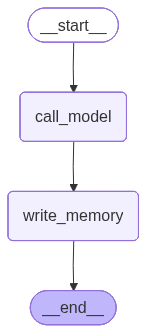

In [12]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.store.base import BaseStore

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_core.runnables.config import RunnableConfig

# Chatbot instruction
MODEL_SYSTEM_MESSAGE = """당신은 사용자에 대한 정보를 제공하는 memory를 가진 친절한 어시스턴트입니다.
해당 사용자에 대한 기억이 있다면, 응답을 개인화하는 데 활용하세요.
기억 내용은 다음과 같습니다(비어 있을 수 있음): {memory}"""

# Create new memory from the chat history and any existing memory
CREATE_MEMORY_INSTRUCTION = """사용자의 채팅 기록을 기반으로 사용자 프로필 memory를 생성하거나 업데이트합니다.
이는 장기 기억을 위해 저장됩니다. 기존 memory가 있는 경우 단순히 업데이트하십시오.
기존 memory는 다음과 같습니다(비어 있을 수 있음): {memory}"""

def call_model(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Load memory from the store and use it to personalize the chatbot's response."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Retrieve memory from the store
    namespace = ("memory", user_id)
    existing_memory = store.get(namespace, "user_memory")

    # Format the memories for the system prompt
    if existing_memory and existing_memory.value:
        memory_dict = existing_memory.value
        formatted_memory = (
            f"Name: {memory_dict.get('user_name', 'Unknown')}\n"
            f"Interests: {', '.join(memory_dict.get('interests', []))}"
        )
    else:
        formatted_memory = None

    # Format the memory in the system prompt
    system_msg = MODEL_SYSTEM_MESSAGE.format(memory=formatted_memory)

    # Respond using memory as well as the chat history
    response = model.invoke([SystemMessage(content=system_msg)]+state["messages"])

    return {"messages": response}

def write_memory(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Reflect on the chat history and save a memory to the store."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Retrieve existing memory from the store
    namespace = ("memory", user_id)
    existing_memory = store.get(namespace, "user_memory")

    # Format the memories for the system prompt
    if existing_memory and existing_memory.value:
        memory_dict = existing_memory.value
        formatted_memory = (
            f"Name: {memory_dict.get('user_name', 'Unknown')}\n"
            f"Interests: {', '.join(memory_dict.get('interests', []))}"
        )
    else:
        formatted_memory = None
        
    # Format the existing memory in the instruction
    system_msg = CREATE_MEMORY_INSTRUCTION.format(memory=formatted_memory)

    # Invoke the model to produce structured output that matches the schema
    new_memory = model_with_structure.invoke([SystemMessage(content=system_msg)]+state['messages'])

    # Overwrite the existing use profile memory
    key = "user_memory"
    store.put(namespace, key, new_memory)

# Define the graph
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_node("write_memory", write_memory)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", "write_memory")
builder.add_edge("write_memory", END)

# Store for long-term (across-thread) memory
across_thread_memory = InMemoryStore()

# Checkpointer for short-term (within-thread) memory
within_thread_memory = MemorySaver()

# Compile the graph with the checkpointer fir and store
graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [13]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory 
config = {"configurable": {"thread_id": "1", "user_id": "1"}}

# User input 
input_messages = [HumanMessage(content="안녕, 내 이름은 유광명이고 송파구에서 테니스치고 빵을 먹는 것을 좋아해.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

안녕, 내 이름은 유광명이고 송파구에서 테니스치고 빵을 먹는 것을 좋아해.
================================== Ai Message ==================================

안녕하세요, 유광명님! 송파구에서 테니스를 치고 빵을 즐기신다니 정말 멋지네요. 테니스는 좋은 운동이고, 맛있는 빵은 언제나 기분을 좋게 해주죠. 요즘 어떤 빵을 가장 좋아하시나요?


store의 memory를 확인해 봅시다.

memory가 우리의 스키마와 일치하는 딕셔너리임을 확인할 수 있습니다.

In [14]:
# Namespace for the memory to save
user_id = "1"
namespace = ("memory", user_id)
existing_memory = across_thread_memory.get(namespace, "user_memory")
existing_memory.value

{'user_name': '유광명', 'interests': ['테니스', '빵 먹기']}

## When can this fail?

[`with_structured_output`](https://docs.langchain.com/oss/python/langchain/models#structured-outputs)은 매우 유용하지만, 더 복잡한 스키마를 다룰 때는 어떻게 될까요? 

[여기](https://github.com/hinthornw/trustcall?tab=readme-ov-file#complex-schema) 아래에서 테스트할 더 복잡한 스키마의 예시가 있습니다.

이것은 사용자의 커뮤니케이션 및 신뢰도 선호도를 설명하는 [Pydantic](https://docs.pydantic.dev/latest/) 모델입니다.

In [16]:
from typing import List, Optional

class OutputFormat(BaseModel):
    preference: str
    sentence_preference_revealed: str

class TelegramPreferences(BaseModel):
    preferred_encoding: Optional[List[OutputFormat]] = None
    favorite_telegram_operators: Optional[List[OutputFormat]] = None
    preferred_telegram_paper: Optional[List[OutputFormat]] = None

class MorseCode(BaseModel):
    preferred_key_type: Optional[List[OutputFormat]] = None
    favorite_morse_abbreviations: Optional[List[OutputFormat]] = None

class Semaphore(BaseModel):
    preferred_flag_color: Optional[List[OutputFormat]] = None
    semaphore_skill_level: Optional[List[OutputFormat]] = None

class TrustFallPreferences(BaseModel):
    preferred_fall_height: Optional[List[OutputFormat]] = None
    trust_level: Optional[List[OutputFormat]] = None
    preferred_catching_technique: Optional[List[OutputFormat]] = None

class CommunicationPreferences(BaseModel):
    telegram: TelegramPreferences
    morse_code: MorseCode
    semaphore: Semaphore

class UserPreferences(BaseModel):
    communication_preferences: CommunicationPreferences
    trust_fall_preferences: TrustFallPreferences

class TelegramAndTrustFallPreferences(BaseModel):
    pertinent_user_preferences: UserPreferences

이제 `with_structured_output` 메서드를 사용하여 이 스키마를 추출해 보겠습니다.

In [17]:
from pydantic import ValidationError

# Bind schema to model
model_with_structure = model.with_structured_output(TelegramAndTrustFallPreferences)

# Conversation
conversation = """운영자: 전보 관련해서 무엇을 도와드릴까요, 고객님?
고객: 저희 신뢰 추락 훈련에 관한 메시지를 보내야 합니다.
운영자: 알겠습니다. 모스 부호로 하시겠습니까, 표준 인코딩으로 하시겠습니까?
고객: 모스 부호로 해주세요. 스트레이트 키로 보내는 걸 좋아하거든요.
운영자: 좋습니다. 메시지는 무엇입니까?
고객: 그에게 말해줘, 더 높은 곳에서 떨어질 준비가 됐다고. 그리고 잡을 때는 다이아몬드 포메이션을 선호한다고.
운영자: 알겠습니다. 이 대담한 메시지에 저희 ‘Daredevil’ 용지를 사용해 드릴까요?
고객: 완벽하군요! 가장 빠른 전령 비둘기로 보내주세요.
운영자: 한 시간 안에 도착할 겁니다, 고객님."""

# Invoke the model
try:
    model_with_structure.invoke(f"""다음 대화에서 선호사항(preferences) 추출하십시오:
    <convo>
    {conversation}
    </convo>""")
except ValidationError as e:
    print(e)

/Users/kmyu/Desktop/project/langchain-study/langchain-academy/intro-to-langgraph/.venv/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=TelegramAndTrustFallPrefe... 선호한다고.')]))), input_type=TelegramAndTrustFallPreferences])
  return self.__pydantic_serializer__.to_python(


만약 우리가 순진하게 더 복잡한 스키마를 추출한다면, `gpt-4o`와 같은 고용량 모델을 사용하더라도 실패하기 쉽다.

## Trustcall for creating and updating profile schemas

스키마 작업은 까다로울 수 있습니다.

복잡한 스키마는 추출하기 어려울 수 있습니다.

또한 단순한 스키마조차 업데이트하는 데 어려움이 따를 수 있습니다.

위에서 살펴본 챗봇을 예로 들어보겠습니다.

새로운 기억을 저장할 때마다 프로필 스키마를 *처음부터* 재생성했습니다.

이는 비효율적이며, 스키마에 매번 재생성해야 할 정보가 많을 경우 모델 토큰을 낭비할 수 있습니다.

더 나쁜 점은 프로필을 처음부터 재생성할 때 정보가 손실될 수 있다는 것입니다.

이러한 문제 해결이 바로 [TrustCall](https://github.com/hinthornw/trustcall)의 개발 동기입니다!

이는 LangChain 팀의 [Will Fu-Hinthorn](https://github.com/hinthornw)이 개발한 JSON 스키마 업데이트용 오픈소스 라이브러리입니다.

메모리 작업 중 정확히 이러한 문제점들에서 영감을 받았습니다.

먼저 [메시지](https://docs.langchain.com/oss/python/langchain/messages) 목록에 대해 TrustCall을 사용한 추출의 간단한 사용법을 보여드리겠습니다.


In [19]:
# Conversation
conversation = [HumanMessage(content="안녕, 내이름은 유광명이야."), 
                AIMessage(content="반가워요. 유광명님."), 
                HumanMessage(content="나는 송파구에서 테니스 치는 것을 좋아해.")]

`create_extractor`를 사용하며, 모델과 함께 스키마를 [도구](https://docs.langchain.com/oss/python/langchain/tools)로 전달합니다.

TrustCall을 사용하면 다양한 방식으로 스키마를 제공할 수 있습니다.

예를 들어, JSON 객체/Python 사전 또는 Pydantic 모델을 전달할 수 있습니다.

내부적으로 TrustCall은 [도구 호출](https://docs.langchain.com/oss/python/langchain/models# tool-calling)을 통해 [메시지](https://docs.langchain.com/oss/python/langchain/messages) 입력 목록으로부터 [구조화된 출력](https://docs.langchain.com/oss/python/langchain/models#structured-outputs)을 생성합니다.

Trustcall이 구조화된 출력을 생성하도록 강제하려면 `tool_choice` 인자에 스키마 이름을 포함시킬 수 있습니다.

위의 대화로 추출기를 호출할 수 있습니다.

In [20]:
from trustcall import create_extractor

# Schema 
class UserProfile(BaseModel):
    """User profile schema with typed fields"""
    user_name: str = Field(description="The user's preferred name")
    interests: List[str] = Field(description="A list of the user's interests")

# Initialize the model
model = ChatOpenAI(model="gpt-4o", temperature=0)

# Create the extractor
trustcall_extractor = create_extractor(
    model,
    tools=[UserProfile], # 도구로 설정
    tool_choice="UserProfile" # 구조화된 출력 설정
)

# Instruction
system_msg = "다음 대화에서 user profile을 추출해줘"

# Invoke the extractor
result = trustcall_extractor.invoke({"messages": [SystemMessage(content=system_msg)]+conversation})

추출기를 호출하면 다음과 같은 결과를 얻습니다:

* `messages`: 도구 호출을 포함하는 `AIMessages` 목록.
* `responses`: 스키마에 맞는 파싱된 도구 호출 결과.
* `response_metadata`: 기존 도구 호출을 업데이트할 때 적용됩니다. 각 응답이 기존 객체 중 어느 것과 대응되는지 알려줍니다.


In [21]:
for m in result["messages"]: 
    m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  UserProfile (call_AdBaQL8UhZpdRpgAS8SACPDc)
 Call ID: call_AdBaQL8UhZpdRpgAS8SACPDc
  Args:
    user_name: 유광명
    interests: ['테니스', '송파구']


In [22]:
schema = result["responses"]
schema

[UserProfile(user_name='유광명', interests=['테니스', '송파구'])]

In [23]:
schema[0].model_dump()

{'user_name': '유광명', 'interests': ['테니스', '송파구']}

In [24]:
result["response_metadata"]

[{'id': 'call_AdBaQL8UhZpdRpgAS8SACPDc'}]

In [25]:
result

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 147, 'total_tokens': 166, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_b558dd220d', 'id': 'chatcmpl-DN5fBlROs8Z7T1bOOvOkwVZIkeP0o', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d2239-7438-7441-90c7-ca1b7b717c2e-0', tool_calls=[{'name': 'UserProfile', 'args': {'user_name': '유광명', 'interests': ['테니스', '송파구']}, 'id': 'call_AdBaQL8UhZpdRpgAS8SACPDc', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 147, 'output_tokens': 19, 'total_tokens': 166, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio

프로필을 *업데이트*하는 데 어떻게 활용할 수 있는지 살펴보겠습니다.

업데이트 시 TrustCall은 기존 스키마와 함께 메시지 집합을 입력으로 받습니다.

핵심 아이디어는 모델이 스키마의 관련 부분만 업데이트하는 [JSON 패치](https://jsonpatch.com/)를 생성하도록 유도하는 것입니다.

이는 스키마 전체를 무분별하게 덮어쓰는 방식보다 오류 발생 가능성이 적습니다.

모델이 변경된 스키마 부분만 생성하면 되므로 효율성도 높습니다.

기존 스키마를 딕셔너리로 저장할 수 있습니다.

`model_dump()`를 사용해 Pydantic 모델 인스턴스를 딕셔너리로 직렬화할 수 있습니다.

이를 스키마 이름 `UserProfile`과 함께 `“existing”` 인자로 전달합니다. 

In [26]:
# Update the conversation
updated_conversation = [HumanMessage(content="안녕, 내이름은 유광명이야"), 
                        AIMessage(content="만나서 반가워요. 광명님."), 
                        HumanMessage(content="나는 송파구에서 테니스 치는 것을 좋아해."),
                        AIMessage(content="송파구는 매우 좋은 동네에요! 테니스 치고나서 뭐해요?"),
                        HumanMessage(content="테니스 치고 나서 빵집에 가는 것을 좋아해."),]

# Update the instruction
system_msg = f"""다음 대화에서 나온 새로운 정보를 반영하여 memory(JSON doc)를 업데이트하십시오"""

# Invoke the extractor with the updated instruction and existing profile with the corresponding tool name (UserProfile)
result = trustcall_extractor.invoke({"messages": [SystemMessage(content=system_msg)]+updated_conversation}, 
                                    {"existing": {"UserProfile": schema[0].model_dump()}})  # model_dump로 pydantic으로 직렬화

In [27]:
for m in result["messages"]: 
    m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  UserProfile (call_fjwaw0Y1HBQ7AIxZE8zSbCdT)
 Call ID: call_fjwaw0Y1HBQ7AIxZE8zSbCdT
  Args:
    user_name: 유광명
    interests: ['테니스', '빵집 방문']


In [28]:
result["response_metadata"]

[{'id': 'call_fjwaw0Y1HBQ7AIxZE8zSbCdT'}]

In [29]:
updated_schema = result["responses"][0]
updated_schema.model_dump()

{'user_name': '유광명', 'interests': ['테니스', '빵집 방문']}

LangSmith trace:

https://smith.langchain.com/public/229eae22-1edb-44c6-93e6-489124a43968/r

Now, let's also test Trustcall on the [challenging schema](https://github.com/hinthornw/trustcall?tab=readme-ov-file#complex-schema) that we saw earlier.

In [30]:
bound = create_extractor(
    model,
    tools=[TelegramAndTrustFallPreferences],
    tool_choice="TelegramAndTrustFallPreferences",
)

# Conversation
conversation = """운영자: 전보 관련해서 무엇을 도와드릴까요, 고객님?
고객: 저희 신뢰 추락 훈련에 관한 메시지를 보내야 합니다.
운영자: 알겠습니다. 모스 부호로 하시겠습니까, 표준 인코딩으로 하시겠습니까?
고객: 모스 부호로 해주세요. 스트레이트 키로 보내는 걸 좋아하거든요.
운영자: 좋습니다. 메시지는 무엇입니까?
고객: 그에게 말해줘, 더 높은 곳에서 떨어질 준비가 됐다고. 그리고 잡을 때는 다이아몬드 포메이션을 선호한다고.
운영자: 알겠습니다. 이 대담한 메시지에 저희 ‘Daredevil’ 용지를 사용해 드릴까요?
고객: 완벽하군요! 가장 빠른 전령 비둘기로 보내주세요.
운영자: 한 시간 안에 도착할 겁니다, 고객님."""

result = bound.invoke(
    f"""Extract the preferences from the following conversation:
<convo>
{conversation}
</convo>"""
)

# Extract the preferences
result["responses"][0]

TelegramAndTrustFallPreferences(pertinent_user_preferences=UserPreferences(communication_preferences=CommunicationPreferences(telegram=TelegramPreferences(preferred_encoding=[OutputFormat(preference='morse code', sentence_preference_revealed='모스 부호로 하시겠습니까?')], favorite_telegram_operators=None, preferred_telegram_paper=[OutputFormat(preference='Daredevil paper', sentence_preference_revealed='이 대담한 메시지에 저희 ‘Daredevil’ 용지를 사용해 드릴까요?')]), morse_code=MorseCode(preferred_key_type=[OutputFormat(preference='straight key', sentence_preference_revealed='스트레이트 키로 보내는 걸 좋아하거든요.')], favorite_morse_abbreviations=None), semaphore=Semaphore(preferred_flag_color=None, semaphore_skill_level=None)), trust_fall_preferences=TrustFallPreferences(preferred_fall_height=[OutputFormat(preference='higher place', sentence_preference_revealed='더 높은 곳에서 떨어질 준비가 됐다고.')], trust_level=None, preferred_catching_technique=[OutputFormat(preference='diamond formation', sentence_preference_revealed='잡을 때는 다이아몬드 포메이션을 선호한다고

Trace: 

https://smith.langchain.com/public/5cd23009-3e05-4b00-99f0-c66ee3edd06e/r

For more examples, you can see an overview video [here](https://www.youtube.com/watch?v=-H4s0jQi-QY).

## Chatbot with profile schema updating

Now, let's bring Trustcall into our chatbot to create *and update* a memory profile.

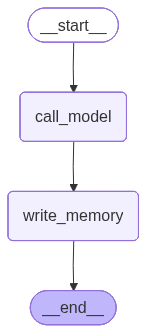

In [26]:
from IPython.display import Image, display

from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.runnables.config import RunnableConfig
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.base import BaseStore

# Initialize the model
model = ChatOpenAI(model="gpt-4o", temperature=0)

# Schema 
class UserProfile(BaseModel):
    """ Profile of a user """
    user_name: str = Field(description="The user's preferred name")
    user_location: str = Field(description="The user's location")
    interests: list = Field(description="A list of the user's interests")

# Create the extractor
trustcall_extractor = create_extractor(
    model,
    tools=[UserProfile],
    tool_choice="UserProfile", # Enforces use of the UserProfile tool
)

# Chatbot instruction
MODEL_SYSTEM_MESSAGE = """당신은 사용자에 대한 정보를 제공하는 memory를 가진 친절한 어시스턴트입니다.
해당 사용자에 대한 기억이 있다면, 응답을 개인화하는 데 활용하세요.
기억 내용은 다음과 같습니다(비어 있을 수 있음): {memory}"""

# Extraction instruction
TRUSTCALL_INSTRUCTION = """Create or update the memory (JSON doc) to incorporate information from the following conversation:"""

def call_model(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Load memory from the store and use it to personalize the chatbot's response."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Retrieve memory from the store
    namespace = ("memory", user_id)
    existing_memory = store.get(namespace, "user_memory")

    # Format the memories for the system prompt
    if existing_memory and existing_memory.value:
        memory_dict = existing_memory.value
        formatted_memory = (
            f"Name: {memory_dict.get('user_name', 'Unknown')}\n"
            f"Location: {memory_dict.get('user_location', 'Unknown')}\n"
            f"Interests: {', '.join(memory_dict.get('interests', []))}"      
        )
    else:
        formatted_memory = None

    # Format the memory in the system prompt
    system_msg = MODEL_SYSTEM_MESSAGE.format(memory=formatted_memory)

    # Respond using memory as well as the chat history
    response = model.invoke([SystemMessage(content=system_msg)]+state["messages"])

    return {"messages": response}

def write_memory(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Reflect on the chat history and save a memory to the store."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Retrieve existing memory from the store
    namespace = ("memory", user_id)
    existing_memory = store.get(namespace, "user_memory")
        
    # Get the profile as the value from the list, and convert it to a JSON doc
    existing_profile = {"UserProfile": existing_memory.value} if existing_memory else None
    
    # Invoke the extractor
    result = trustcall_extractor.invoke({"messages": [SystemMessage(content=TRUSTCALL_INSTRUCTION)]+state["messages"], "existing": existing_profile})
    
    # Get the updated profile as a JSON object
    updated_profile = result["responses"][0].model_dump()

    # Save the updated profile
    key = "user_memory"
    store.put(namespace, key, updated_profile)

# Define the graph
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_node("write_memory", write_memory)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", "write_memory")
builder.add_edge("write_memory", END)

# Store for long-term (across-thread) memory
across_thread_memory = InMemoryStore()

# Checkpointer for short-term (within-thread) memory
within_thread_memory = MemorySaver()

# Compile the graph with the checkpointer fir and store
graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [27]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory 
config = {"configurable": {"thread_id": "1", "user_id": "1"}}

# User input 
input_messages = [HumanMessage(content="안녕, 내이름은 유광명이야.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

안녕, 내이름은 유광명이야.
================================== Ai Message ==================================

안녕하세요, 유광명님! 만나서 반갑습니다. 오늘 어떻게 도와드릴까요?


In [28]:
# User input 
input_messages = [HumanMessage(content="나는 송파구에서 테니스 치는 것을 좋아해.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

나는 송파구에서 테니스 치는 것을 좋아해.
================================== Ai Message ==================================

송파구에서 테니스를 즐기시는군요! 테니스는 정말 좋은 운동이죠. 송파구에는 테니스 코트가 많이 있나요? 아니면 자주 가시는 특정 장소가 있나요?


In [29]:
# Namespace for the memory to save
user_id = "1"
namespace = ("memory", user_id)
existing_memory = across_thread_memory.get(namespace, "user_memory")
existing_memory.dict()

{'namespace': ['memory', '1'],
 'key': 'user_memory',
 'value': {'user_name': '유광명', 'user_location': '송파구', 'interests': ['테니스']},
 'created_at': '2026-03-02T23:34:45.677972+00:00',
 'updated_at': '2026-03-02T23:34:45.677973+00:00'}

In [30]:
# The user profile saved as a JSON object
existing_memory.value

{'user_name': '유광명', 'user_location': '송파구', 'interests': ['테니스']}

In [31]:
# User input 
input_messages = [HumanMessage(content="나는 빵집 가는 것도 좋아해.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

나는 빵집 가는 것도 좋아해.
================================== Ai Message ==================================

빵집을 좋아하시는군요! 송파구에는 맛있는 빵집들이 많을 것 같아요. 혹시 자주 가시는 빵집이나 추천하고 싶은 곳이 있나요? 새로운 빵집을 찾는 것도 재미있을 것 같아요.


Continue the conversation in a new thread.

In [32]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory 
config = {"configurable": {"thread_id": "2", "user_id": "1"}}

# User input 
input_messages = [HumanMessage(content="빵집 추천해줄래?")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

빵집 추천해줄래?
================================== Ai Message ==================================

송파구에 계시니, 그 근처의 빵집을 추천해드릴게요. 

1. **르 알래스카**: 프랑스식 베이커리로, 크루아상과 바게트가 특히 유명합니다.
2. **밀도**: 다양한 종류의 식빵을 전문으로 하는 곳으로, 부드럽고 촉촉한 식빵이 인기입니다.
3. **마마스 베이커리**: 건강한 재료로 만든 다양한 빵과 디저트를 제공합니다.

이 중에서 한 번 방문해보시면 좋을 것 같아요! 테니스 후에 맛있는 빵을 즐기시면 더욱 좋겠네요.


Trace:

https://smith.langchain.com/public/f45bdaf0-6963-4c19-8ec9-f4b7fe0f68ad/r

## Studio

![Screenshot 2024-10-30 at 11.26.31 AM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/6732d0437060f1754ea79908_Screenshot%202024-11-11%20at%207.48.53%E2%80%AFPM.png)